In [25]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
# Importing imblearn, scikit-learn library
from imblearn.over_sampling import SMOTE
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter


In [26]:
df = pd.read_excel("IAV-training-PU-label1.xlsx")
# df = pd.read_csv("final_training.csv")
# df['Label'] = df['Label'].replace(np.nan, 0)
df=df.drop(["Residue_Index", "PDBID","PU"], axis=1)
# df=df.drop(["Residue_Index", "PDBID", "Secondary_Structure", "Junction_Region","Chain"], axis=1)
df["Valine_Propensity"]=df["Valine_Propensity"].apply(lambda x:x*-1)
df["Serine_Propensity"]=df["Serine_Propensity"].apply(lambda x:x*-1)
df["Methionine_Propensity"]=df["Methionine_Propensity"].apply(lambda x:x*-1)
df["Threonine_Propensity"]=df["Threonine_Propensity"].apply(lambda x:x*-1)
df["Leucine_Propensity"]=df["Leucine_Propensity"].apply(lambda x:x*-1)
aa_to_number = {
    'A': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5,
    'G': 6, 'H': 7, 'I': 8, 'K': 9, 'L': 10,
    'M': 11, 'N': 12, 'P': 13, 'Q': 14, 'R': 15,
    'S': 16, 'T': 17, 'V': 18, 'W': 19, 'Y': 20
}
# label="PDBID"
# classes= df[label].unique().tolist()
# print(f"Label classes: {classes}")
# df[label]= df[label].map(classes.index)

# Convert Amino_Acid column to numbers
df['Amino_Acid'] = df['Amino_Acid'].map(aa_to_number)
df

,Amino_Acid,Arginine_Propensity,Tryptophan_Propensity,Tyrosine_Propensity,Valine_Propensity,Serine_Propensity,Methionine_Propensity,Threonine_Propensity,Leucine_Propensity,RelSASA,Secondary_Enum,label
0,11,0.000000,0.0,0.0,-0.0,-0.000000,-0.000000,-0.0,-0.000000,0.783568,0.942029,0
1,4,0.000000,0.0,0.0,-0.0,-0.000000,-0.000000,-0.0,-0.000000,0.742773,0.942029,0
2,15,0.000000,0.0,0.0,-0.0,-0.000000,-0.000000,-0.0,-0.000000,0.592849,0.130701,1
3,8,0.142857,0.0,0.0,-0.0,-0.000000,-0.142857,-0.0,-0.142857,0.516733,0.130701,0
4,9,0.285714,0.0,0.0,-0.0,-0.000000,-0.000000,-0.0,-0.142857,0.942029,0.130701,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3317,16,0.142857,0.0,0.0,-0.0,-0.142857,-0.000000,-0.0,-0.142857,0.435100,0.276250,1
3318,5,0.000000,0.0,0.0,-0.0,-0.142857,-0.000000,-0.0,-0.142857,0.731220,0.276250,0
3319,14,0.000000,0.0,0.0,-0.0,-0.000000,-0.000000,-0.0,-0.000000,0.695062,0.942029,0
3320,10,0.000000,0.0,0.0,-0.0,-0.000000,-0.000000,-0.0,-0.000000,0.942029,0.942029,0


In [27]:
df['label'].sum()

1635

In [28]:
X= df.drop('label', axis=1)
y=df["label"]

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_recall_curve, auc

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Instantiate Gradient Boosting Regressor
model1 = GradientBoostingClassifier(n_estimators=500,
                                 learning_rate=0.1,
                                 random_state=130)
#without oversampling
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)

#SMOTE
smote = SMOTE(random_state=42)
X_res2, y_res2 = smote.fit_resample(X_train, y_train)
model2 = GradientBoostingClassifier(n_estimators=500,
                                 learning_rate=0.1,
                                 random_state=130)
model2.fit(X_res2, y_res2)
y_pred2 = model2.predict(X_test)

#RandomSampler
ros = RandomOverSampler(random_state=42)
X_res3, y_res3 = ros.fit_resample(X_train, y_train)
model3 = GradientBoostingClassifier(n_estimators=500,
                                 learning_rate=0.1,
                                 random_state=130)
model3.fit(X_res3, y_res3)
y_pred3 = model3.predict(X_test)


In [48]:
print("Accuracy Score without oversampling:", accuracy_score(y_test, y_pred1))
print("Accuracy Score with SMOTE:", accuracy_score(y_test, y_pred2))
print("Accuracy Score with RandomSampler:", accuracy_score(y_test, y_pred3))
print("Classification Report without oversampling:\n", classification_report(y_test, y_pred1))
print("Classification Report with SMOTE:\n", classification_report(y_test, y_pred2))
print("Classification Report with RandomSampler:\n", classification_report(y_test, y_pred3))

# 5. Predict probabilities for PR curve
y_scores1 = model1.predict_proba(X_test)[:, 1]
y_scores2 = model2.predict_proba(X_test)[:, 1]
y_scores3 = model3.predict_proba(X_test)[:, 1]

# 6. Calculate the Precision-Recall curve and AUC
precision1, recall1, _ = precision_recall_curve(y_test, y_scores1)
pr_auc1 = auc(recall1, precision1)

precision2, recall2, _ = precision_recall_curve(y_test, y_scores2)
pr_auc2 = auc(recall2, precision2)

precision3, recall3, _ = precision_recall_curve(y_test, y_scores3)
pr_auc3 = auc(recall3, precision3)

print(f'PR AUC Score without oversampling: {pr_auc1:.2f}')
print(f'PR AUC Score with SMOTE: {pr_auc2:.2f}')
print(f'PR AUC Score with RandomSampler: {pr_auc3:.2f}')

# import matplotlib.pyplot as plt

# plt.figure()
# plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curve')
# plt.legend()
# plt.grid(True)
# plt.show()

Accuracy Score without oversampling: 0.9518796992481203
Accuracy Score with SMOTE: 0.9533834586466166
Accuracy Score with RandomSampler: 0.9518796992481203
Classification Report without oversampling:
               precision    recall  f1-score   support

           0       0.96      0.95      0.95       338
           1       0.95      0.95      0.95       327

    accuracy                           0.95       665
   macro avg       0.95      0.95      0.95       665
weighted avg       0.95      0.95      0.95       665

Classification Report with SMOTE:
               precision    recall  f1-score   support

           0       0.96      0.95      0.95       338
           1       0.95      0.95      0.95       327

    accuracy                           0.95       665
   macro avg       0.95      0.95      0.95       665
weighted avg       0.95      0.95      0.95       665

Classification Report with RandomSampler:
               precision    recall  f1-score   support

           0

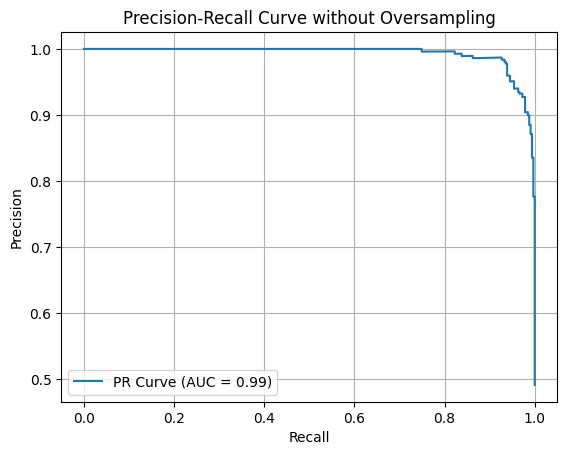

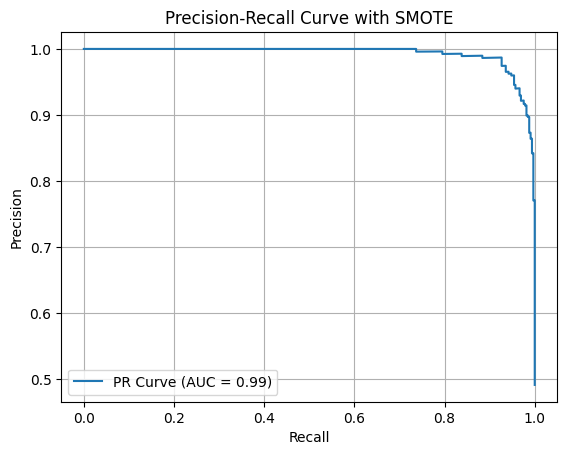

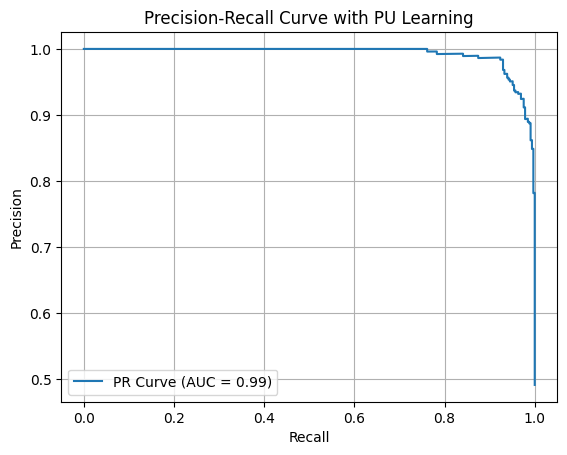

In [31]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(recall1, precision1, label=f'PR Curve (AUC = {pr_auc1:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve without Oversampling')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(recall2, precision2, label=f'PR Curve (AUC = {pr_auc2:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve with SMOTE')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(recall3, precision3, label=f'PR Curve (AUC = {pr_auc3:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve with PU Learning')
plt.legend()
plt.grid(True)
plt.show()

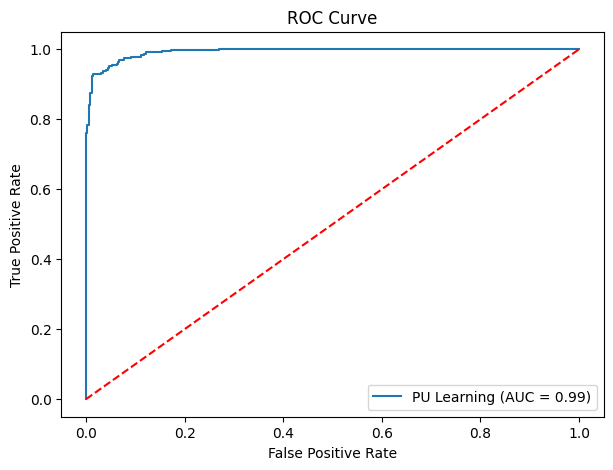

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
test_df = pd.DataFrame(
    {'True': y_test, 'PU Learning': y_scores3})
plt.figure(figsize=(7, 5))

for model in ['PU Learning']:
    fpr, tpr, _ = roc_curve(test_df['True'], test_df[model])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'r--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

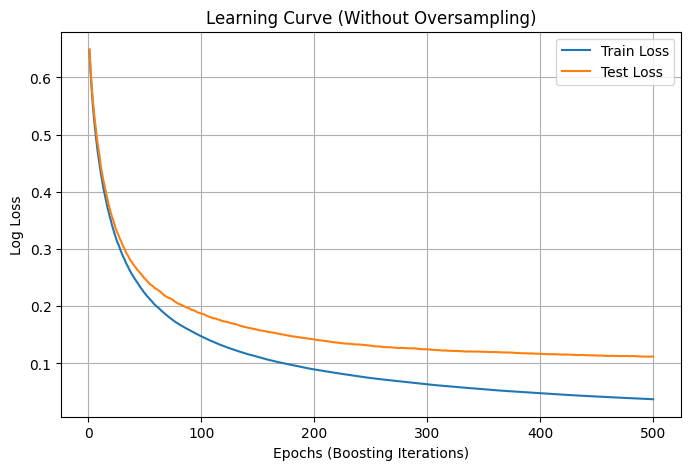

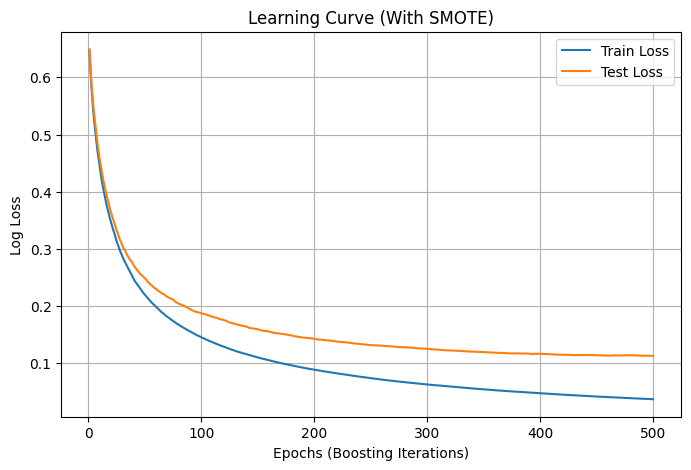

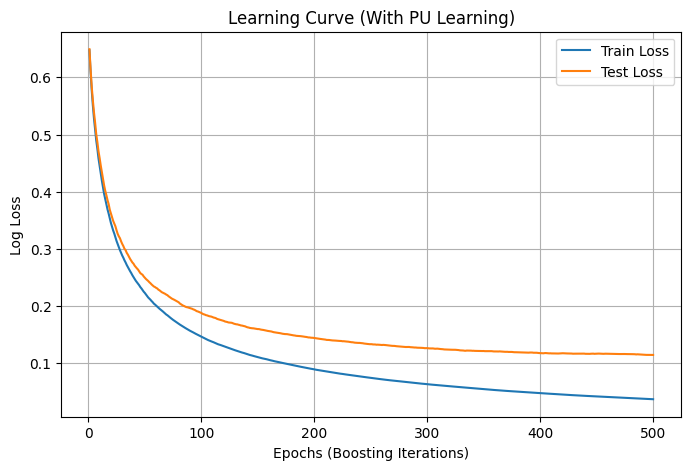

In [52]:
from sklearn.metrics import log_loss

train_losses = []
test_losses = []
for y_train_pred, y_test_pred in zip(
    model1.staged_predict_proba(X_train),
    model1.staged_predict_proba(X_test)
):
    train_losses.append(log_loss(y_train, y_train_pred))
    test_losses.append(log_loss(y_test, y_test_pred))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
plt.plot(range(1, len(test_losses) + 1), test_losses, label="Test Loss")
plt.xlabel("Epochs (Boosting Iterations)")
plt.ylabel("Log Loss")
plt.title("Learning Curve (Without Oversampling)")
plt.legend()
plt.grid(True)
plt.show()

train_losses = []
test_losses = []
for y_train_pred, y_test_pred in zip(
    model2.staged_predict_proba(X_res2),
    model2.staged_predict_proba(X_test)
):
    train_losses.append(log_loss(y_res2, y_train_pred))
    test_losses.append(log_loss(y_test, y_test_pred))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
plt.plot(range(1, len(test_losses) + 1), test_losses, label="Test Loss")
plt.xlabel("Epochs (Boosting Iterations)")
plt.ylabel("Log Loss")
plt.title("Learning Curve (With SMOTE)")
plt.legend()
plt.grid(True)
plt.show()

train_losses = []
test_losses = []
for y_train_pred, y_test_pred in zip(
    model3.staged_predict_proba(X_res3),
    model3.staged_predict_proba(X_test)
):
    train_losses.append(log_loss(y_res3, y_train_pred))
    test_losses.append(log_loss(y_test, y_test_pred))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
plt.plot(range(1, len(test_losses) + 1), test_losses, label="Test Loss")
plt.xlabel("Epochs (Boosting Iterations)")
plt.ylabel("Log Loss")
plt.title("Learning Curve (With PU Learning)")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
# df1 = pd.read_csv("viral-test.csv")
df1 = pd.read_csv("SARS-COV2-final.csv")
df1 = df1.drop(["Residue_Index","Secondary_Structure", "Junction_Region","Label"], axis=1)
df1["Valine_Propensity"]=df1["Valine_Propensity"].apply(lambda x:x*-1)
df1["Serine_Propensity"]=df1["Serine_Propensity"].apply(lambda x:x*-1)
df1["Methionine_Propensity"]=df1["Methionine_Propensity"].apply(lambda x:x*-1)
df1["Threonine_Propensity"]=df1["Threonine_Propensity"].apply(lambda x:x*-1)
df1["Leucine_Propensity"]=df1["Leucine_Propensity"].apply(lambda x:x*-1)
# label="PDBID"
# classes= df1[label].unique().tolist()
# print(f"Label classes: {classes}")
# df1[label]= df1[label].map(classes.index)
aa_to_number = {
    'A': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5,
    'G': 6, 'H': 7, 'I': 8, 'K': 9, 'L': 10,
    'M': 11, 'N': 12, 'P': 13, 'Q': 14, 'R': 15,
    'S': 16, 'T': 17, 'V': 18, 'W': 19, 'Y': 20
}

# Convert Amino_Acid column to numbers
df1['Amino_Acid'] = df1['Amino_Acid'].map(aa_to_number)
df1

,Amino_Acid,Arginine_Propensity,Tryptophan_Propensity,Tyrosine_Propensity,Valine_Propensity,Serine_Propensity,Methionine_Propensity,Threonine_Propensity,Leucine_Propensity,RelSASA,Secondary_Enum
0,10,0.000000,0.0,0.0,-0.0,-0.000000,-0.0,-0.0,-0.142857,0.388558,0.171340
1,6,0.000000,0.0,0.0,-0.0,-0.000000,-0.0,-0.0,-0.142857,0.498761,0.942029
2,9,0.000000,0.0,0.0,-0.0,-0.000000,-0.0,-0.0,-0.142857,0.749259,0.942029
3,6,0.142857,0.0,0.0,-0.0,-0.000000,-0.0,-0.0,-0.142857,0.499994,0.942029
4,3,0.142857,0.0,0.0,-0.0,-0.000000,-0.0,-0.0,-0.000000,0.313203,0.942029
...,...,...,...,...,...,...,...,...,...,...,...
190,9,0.000000,0.0,0.0,-0.0,-0.000000,-0.0,-0.0,-0.142857,0.630122,0.130700
191,2,0.000000,0.0,0.0,-0.0,-0.142857,-0.0,-0.0,-0.142857,0.185043,0.942029
192,3,0.000000,0.0,0.0,-0.0,-0.142857,-0.0,-0.0,-0.000000,0.619497,0.942029
193,8,0.000000,0.0,0.0,-0.0,-0.142857,-0.0,-0.0,-0.000000,0.282040,0.433300


In [35]:
predictions1 = model1.predict(df1)
print("Predicted Labels without oversampling:")
print(predictions1)
csv_file_path = "gb-preds1.csv"

predictions2 = model2.predict(df1)
print("Predicted Labels with SMOTE:")
print(predictions2)
csv_file_path = "gb-preds2.csv"

predictions3 = model3.predict(df1)
print("Predicted Labels with RandomSampler:")
print(predictions3)
csv_file_path = "gb-preds3.csv"


result_df1 = pd.DataFrame({'Predicted_Labels without oversampling': predictions1.flatten()})
result_df1.to_csv(csv_file_path, index=False)

result_df2 = pd.DataFrame({'Predicted_Labels with SMOTE': predictions2.flatten()})
result_df2.to_csv(csv_file_path, index=False)

result_df3 = pd.DataFrame({'Predicted_Labels with RandomSampler': predictions3.flatten()})
result_df3.to_csv(csv_file_path, index=False)


Predicted Labels without oversampling:
[1 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 1 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 1 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1
 1 1 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0
 0 0 0 0 0 0 1 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1
 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1
 0 0 0 1 1 1 0 0 1 1]
Predicted Labels with SMOTE:
[1 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 1 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 1 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1
 1 1 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0
 0 0 0 0 0 0 1 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1
 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1
 0 0 0 1 1 1 0 0 1 1]
Predicted Labels with RandomSampler:
[1 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 1 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 1 0 0 0 0 1 0 0 1

In [36]:
df2 = pd.read_csv("SARS-COV2-final.csv")
test=df2['Label']

print("Classification Report without oversampling:\n", classification_report(test, predictions1))
print("Classification Report with SMOTE:\n", classification_report(test, predictions2))
print("Classification Report with RandomSampler:\n", classification_report(test, predictions3))


Classification Report without oversampling:
               precision    recall  f1-score   support

           0       0.59      0.35      0.44       126
           1       0.32      0.55      0.40        69

    accuracy                           0.42       195
   macro avg       0.45      0.45      0.42       195
weighted avg       0.49      0.42      0.43       195

Classification Report with SMOTE:
               precision    recall  f1-score   support

           0       0.59      0.35      0.44       126
           1       0.32      0.55      0.40        69

    accuracy                           0.42       195
   macro avg       0.45      0.45      0.42       195
weighted avg       0.49      0.42      0.43       195

Classification Report with RandomSampler:
               precision    recall  f1-score   support

           0       0.59      0.35      0.44       126
           1       0.32      0.55      0.40        69

    accuracy                           0.42       195
   ma

In [37]:
# df1 = pd.read_csv("viral-test.csv")
df2 = pd.read_csv("h5n1.csv")
df2['Label'] = df2['Label'].replace(np.nan, 0)
df2 = df2.drop(["Residue_Index","Secondary_Structure", "Junction_Region","Label","PDBID"], axis=1)
df2["Valine_Propensity"]=df2["Valine_Propensity"].apply(lambda x:x*-1)
df2["Serine_Propensity"]=df2["Serine_Propensity"].apply(lambda x:x*-1)
df2["Methionine_Propensity"]=df2["Methionine_Propensity"].apply(lambda x:x*-1)
df2["Threonine_Propensity"]=df2["Threonine_Propensity"].apply(lambda x:x*-1)
df2["Leucine_Propensity"]=df2["Leucine_Propensity"].apply(lambda x:x*-1)
# label="PDBID"
# classes= df1[label].unique().tolist()
# print(f"Label classes: {classes}")
# df1[label]= df1[label].map(classes.index)
aa_to_number = {
    'A': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5,
    'G': 6, 'H': 7, 'I': 8, 'K': 9, 'L': 10,
    'M': 11, 'N': 12, 'P': 13, 'Q': 14, 'R': 15,
    'S': 16, 'T': 17, 'V': 18, 'W': 19, 'Y': 20
}

# Convert Amino_Acid column to numbers
df2['Amino_Acid'] = df2['Amino_Acid'].map(aa_to_number)
df2

,Amino_Acid,Arginine_Propensity,Tryptophan_Propensity,Tyrosine_Propensity,Valine_Propensity,Serine_Propensity,Methionine_Propensity,Threonine_Propensity,Leucine_Propensity,RelSASA,Secondary_Enum
0,11,0.000000,0.0,0.0,-0.000000,-0.250000,-0.250000,-0.000000,-0.0,0.821871,0.4333
1,1,0.000000,0.0,0.0,-0.000000,-0.200000,-0.200000,-0.000000,-0.0,0.788835,0.4333
2,16,0.000000,0.0,0.0,-0.000000,-0.166667,-0.166667,-0.166667,-0.0,0.777544,0.4333
3,14,0.000000,0.0,0.0,-0.000000,-0.142857,-0.142857,-0.142857,-0.0,0.755300,0.4333
4,6,0.142857,0.0,0.0,-0.000000,-0.142857,-0.000000,-0.142857,-0.0,0.763420,0.4333
...,...,...,...,...,...,...,...,...,...,...,...
723,8,0.142857,0.0,0.0,-0.000000,-0.000000,-0.000000,-0.142857,-0.0,0.332287,0.4333
724,4,0.142857,0.0,0.0,-0.142857,-0.000000,-0.000000,-0.142857,-0.0,0.482853,0.4333
725,13,0.000000,0.0,0.0,-0.166667,-0.000000,-0.000000,-0.166667,-0.0,0.459241,0.4333
726,4,0.000000,0.0,0.0,-0.200000,-0.000000,-0.000000,-0.000000,-0.0,0.510160,0.4333


In [38]:
predictions1 = model1.predict(df2)
print("Predicted Labels without oversampling:")
print(predictions1)
csv_file_path = "gb-preds1.csv"

predictions2 = model2.predict(df2)
print("Predicted Labels with SMOTE:")
print(predictions2)
csv_file_path = "gb-preds2.csv"

predictions3 = model3.predict(df2)
print("Predicted Labels with RandomSampler:")
print(predictions3)
csv_file_path = "gb-preds3.csv"


result_df1 = pd.DataFrame({'Predicted_Labels without oversampling': predictions1.flatten()})
result_df1.to_csv(csv_file_path, index=False)

result_df2 = pd.DataFrame({'Predicted_Labels with SMOTE': predictions2.flatten()})
result_df2.to_csv(csv_file_path, index=False)

result_df3 = pd.DataFrame({'Predicted_Labels with RandomSampler': predictions3.flatten()})
result_df3.to_csv(csv_file_path, index=False)


Predicted Labels without oversampling:
[0 0 0 0 0 1 1 1 1 0 0 1 1 0 0 0 0 0 0 1 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 1 1
 1 1 1 1 1 1 0 1 0 0 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0 0
 1 1 1 1 1 1 0 0 1 1 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 1 1 0 1 1 1 1
 1 1 1 0 1 1 0 0 0 1 1 0 0 1 0 1 1 1 1 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 1 1
 1 1 1 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 1 1 1 1
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 1
 0 0 0 1 1 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 1 1 1 0 1
 0 1 1 0 0 1 1 0 0 0 1 0 0 0 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 0 1 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0 0 1 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0
 0 1 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 0 0 1 0 1 0 1 1 0 1
 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 0 1 0 0 1
 1 1 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 1 1 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 1 1 

In [39]:
df3 = pd.read_csv("h5n1.csv")
df3['Label'] = df3['Label'].replace(np.nan, 0)
test=df3['Label']
print("Classification Report without oversampling:\n", classification_report(test, predictions1))
print("Classification Report with SMOTE:\n", classification_report(test, predictions2))
print("Classification Report with RandomSampler:\n", classification_report(test, predictions3))

Classification Report without oversampling:
               precision    recall  f1-score   support

         0.0       0.89      0.52      0.66       665
         1.0       0.05      0.29      0.09        63

    accuracy                           0.50       728
   macro avg       0.47      0.40      0.37       728
weighted avg       0.81      0.50      0.61       728

Classification Report with SMOTE:
               precision    recall  f1-score   support

         0.0       0.89      0.52      0.66       665
         1.0       0.05      0.29      0.09        63

    accuracy                           0.50       728
   macro avg       0.47      0.40      0.37       728
weighted avg       0.81      0.50      0.61       728

Classification Report with RandomSampler:
               precision    recall  f1-score   support

         0.0       0.88      0.52      0.65       665
         1.0       0.05      0.29      0.09        63

    accuracy                           0.50       728
   ma

In [40]:
# df1 = pd.read_csv("viral-test.csv")
df4 = pd.read_csv("viral-test.csv")
df4 = df4.drop(["Residue_Index","Secondary_Structure", "Junction_Region","Protein","PDBID"], axis=1)
df4["Valine_Propensity"]=df4["Valine_Propensity"].apply(lambda x:x*-1)
df4["Serine_Propensity"]=df4["Serine_Propensity"].apply(lambda x:x*-1)
df4["Methionine_Propensity"]=df4["Methionine_Propensity"].apply(lambda x:x*-1)
df4["Threonine_Propensity"]=df4["Threonine_Propensity"].apply(lambda x:x*-1)
df4["Leucine_Propensity"]=df4["Leucine_Propensity"].apply(lambda x:x*-1)
# label="PDBID"
# classes= df1[label].unique().tolist()
# print(f"Label classes: {classes}")
# df1[label]= df1[label].map(classes.index)
aa_to_number = {
    'A': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5,
    'G': 6, 'H': 7, 'I': 8, 'K': 9, 'L': 10,
    'M': 11, 'N': 12, 'P': 13, 'Q': 14, 'R': 15,
    'S': 16, 'T': 17, 'V': 18, 'W': 19, 'Y': 20
}

# Convert Amino_Acid column to numbers
df4['Amino_Acid'] = df4['Amino_Acid'].map(aa_to_number)
df4

,Amino_Acid,Arginine_Propensity,Tryptophan_Propensity,Tyrosine_Propensity,Valine_Propensity,Serine_Propensity,Methionine_Propensity,Threonine_Propensity,Leucine_Propensity,RelSASA,Secondary_Enum
0,11,0.250000,0.0,0.0,-0.000000,-0.0,-0.250000,-0.0,-0.000000,0.635686,0.942029
1,4,0.200000,0.0,0.0,-0.000000,-0.0,-0.200000,-0.0,-0.000000,0.689330,0.942029
2,15,0.166667,0.0,0.0,-0.000000,-0.0,-0.166667,-0.0,-0.000000,0.470975,0.130700
3,8,0.142857,0.0,0.0,-0.000000,-0.0,-0.142857,-0.0,-0.142857,0.265970,0.130700
4,9,0.285714,0.0,0.0,-0.000000,-0.0,-0.000000,-0.0,-0.142857,0.554636,0.130700
...,...,...,...,...,...,...,...,...,...,...,...
27075,11,0.142857,0.0,0.0,-0.142857,-0.0,-0.142857,-0.0,-0.000000,0.581878,0.433300
27076,14,0.142857,0.0,0.0,-0.142857,-0.0,-0.142857,-0.0,-0.000000,0.551159,0.433300
27077,15,0.166667,0.0,0.0,-0.000000,-0.0,-0.166667,-0.0,-0.000000,0.372895,0.433300
27078,5,0.200000,0.0,0.0,-0.000000,-0.0,-0.200000,-0.0,-0.000000,0.486791,0.433300


In [41]:
predictions1 = model1.predict(df4)
print("Predicted Labels without oversampling:")
print(predictions1)
csv_file_path = "gb-preds1-train1-viral-test.csv"

predictions2 = model2.predict(df4)
print("Predicted Labels with SMOTE:")
print(predictions2)
csv_file_path = "gb-preds2-train1-viral-test.csv"

predictions3 = model3.predict(df4)
print("Predicted Labels with RandomSampler:")
print(predictions3)
csv_file_path1 = "gb-preds-train2-viral-test-no-os-pu.csv"
csv_file_path2 = "gb-preds-train2-viral-test-smote-pu.csv"
csv_file_path3 = "gb-preds-train2-viral-test-rs-pu.csv"


result_df1 = pd.DataFrame({'Predicted_Labels without oversampling': predictions1.flatten()})
result_df1.to_csv(csv_file_path1, index=False)

result_df2 = pd.DataFrame({'Predicted_Labels with SMOTE': predictions2.flatten()})
result_df2.to_csv(csv_file_path2, index=False)

result_df3 = pd.DataFrame({'Predicted_Labels with RandomSampler': predictions3.flatten()})
result_df3.to_csv(csv_file_path3, index=False)

Predicted Labels without oversampling:
[0 0 0 ... 0 0 0]
Predicted Labels with SMOTE:
[0 0 0 ... 0 0 0]
Predicted Labels with RandomSampler:
[0 0 0 ... 0 0 0]
